# Loading Emotion Dataset

In [3]:
import pandas as pd

In [42]:
from datasets import load_dataset 
emotions = load_dataset("emotion")

In [43]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
# Converting to Pandas DataFrame
emotions.set_format(type='pandas')

In [7]:
df= emotions["train"][:]

In [8]:
classes= emotions["train"].features["label"].names
df["lable_name"]= df["label"].apply(lambda x: classes[x])

In [9]:
df.head()

,text,label,lable_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## Dataset Analysis

In [10]:
import matplotlib.pyplot as plt

In [11]:
df["lable_name"].value_counts(ascending=True)

lable_name
surprise     572
love        1304
fear        1937
anger       2159
sadness     4666
joy         5362
Name: count, dtype: int64

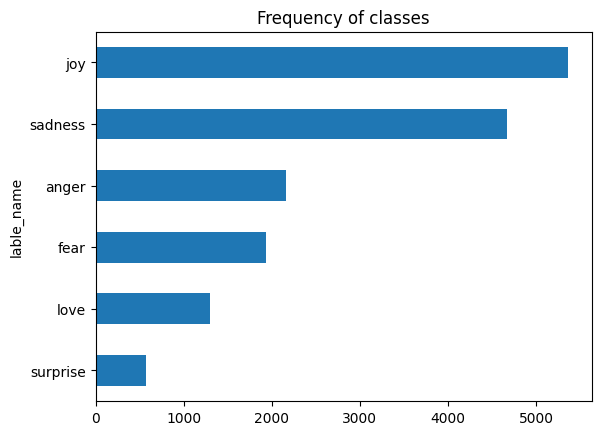

In [12]:
df["lable_name"].value_counts(ascending=True).plot.barh()
plt.title('Frequency of classes')
plt.show()

In [13]:
df.head()

,text,label,lable_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


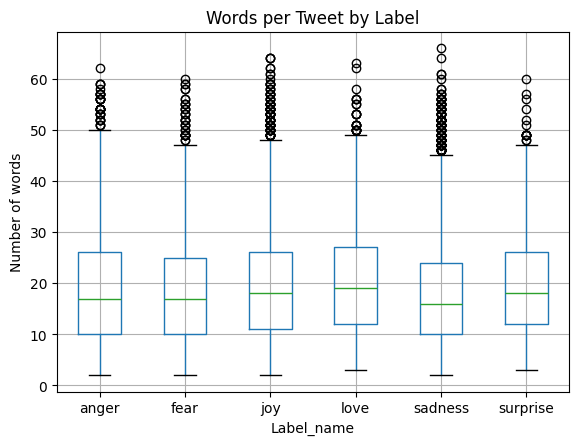

In [14]:
df["words_per_tweet"]=df["text"].str.split().apply(len)
df.boxplot(column="words_per_tweet", by="lable_name")
plt.title('Words per Tweet by Label')
plt.xlabel("Label_name")
plt.ylabel("Number of words")
plt.suptitle("") # Removes the default title
plt.show()

# Text to Tokens Conversion
- Transformer models like DistilBERT cannot receive raw strings as input; instead, they assume the text has been tokenized and encoded as numerical vectors.
- Tokenization is the step of breaking down a string into the atomic units used in the model

In [15]:
from transformers import AutoTokenizer 
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

In [16]:
tokenizer.vocab_size, tokenizer.model_max_length

(30522, 512)

## Tokenization Of Dataset

In [17]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [52]:
emotions.reset_format()

In [19]:
def tokenize(batch):
    return tokenizer(batch["text"], padding =True, truncation=True)

In [20]:
tokenize(emotions["train"][:2])

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [21]:
emotion_encoded = emotions.map(tokenize, batched= True, batch_size=None)

In [22]:
emotion_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## Model Building

In [23]:
from transformers import AutoModel
import torch

In [24]:
model = AutoModel.from_pretrained("distilbert-base-uncased")

## Fine Tuning Transformer

- 'AutoModelForSequenceClassification' model has a classification head on top of the pretrained model outputs
- The first thing we need is a pretrained DistilBERT model like the one we used in the feature-based approach.
- The only slight modification is that we use the AutoModelForSequenceClassification model instead of AutoModel.
- The difference is that the AutoModelForSequenceClassification model has a classification head on top of the pretrained model outputs, which can be easily trained with the base model.

- Model Architecture

    hidden_size = 768

    layers = 6

    heads = 12

    dropout = 0.1

In [25]:
len(classes)

6

In [54]:
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

label2id = {v: k for k, v in id2label.items()}

In [55]:
from transformers import AutoModelForSequenceClassification

num_labels = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels = num_labels,id2label=id2label).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [56]:
from transformers import TrainingArguments

In [57]:
batch_size = 64
model_name = "distilbert-finetuned-emotion"

training_args = TrainingArguments(output_dir = model_name,
                                 num_train_epochs=2,
                                 learning_rate = 2e-5,
                                 per_device_train_batch_size= batch_size,
                                 per_device_eval_batch_size = batch_size,
                                  weight_decay=0.01,
                                  evaluation_strategy = 'epoch',
                                  disable_tqdm=False)

/home/hitman/python/venv/lib/python3.11/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [58]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

In [59]:

from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=emotion_encoded['train'],
                  eval_dataset=emotion_encoded['validation'],
                  tokenizer=tokenizer)

/tmp/ipykernel_379023/2940103940.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, args=training_args,


In [60]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.325234,0.907500,0.907018
2,0.563700,0.233352,0.922000,0.921948


TrainOutput(global_step=500, training_loss=0.56371826171875, metrics={'train_runtime': 151.3363, 'train_samples_per_second': 211.45, 'train_steps_per_second': 3.304, 'total_flos': 720342861696000.0, 'train_loss': 0.56371826171875, 'epoch': 2.0})

In [62]:
preds_outputs = trainer.predict(emotion_encoded['test'])
preds_outputs.metrics

{'test_loss': 0.22969791293144226,
 'test_accuracy': 0.913,
 'test_f1': 0.9125288049427644,
 'test_runtime': 2.3572,
 'test_samples_per_second': 848.469,
 'test_steps_per_second': 13.576}

In [63]:
import numpy as np
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = emotion_encoded['test'][:]['label']

In [64]:
from sklearn.metrics import classification_report
print(classes)
print(classification_report(y_true, y_preds))

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       581
           1       0.93      0.93      0.93       695
           2       0.77      0.79      0.78       159
           3       0.91      0.93      0.92       275
           4       0.89      0.88      0.88       224
           5       0.77      0.65      0.70        66

    accuracy                           0.91      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.91      0.91      0.91      2000



In [65]:
text = 'i want to kill you'
input_encoded = tokenizer(text, return_tensors='pt', return_token_type_ids=False).to(device)
with torch.no_grad():
  outputs = model(**input_encoded)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()
pred, classes[pred]

(3, 'anger')

# Saving and Using the model


In [66]:
from huggingface_hub import notebook_login 
notebook_login()

In [67]:
trainer.push_to_hub(commit_message="Training completed!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/NOtda/distilbert-finetuned-emotion/commit/2a7325069bc6201d8937f7b7da40a939161b1537', commit_message='Training completed!', commit_description='', oid='2a7325069bc6201d8937f7b7da40a939161b1537', pr_url=None, repo_url=RepoUrl('https://huggingface.co/NOtda/distilbert-finetuned-emotion', endpoint='https://huggingface.co', repo_type='model', repo_id='NOtda/distilbert-finetuned-emotion'), pr_revision=None, pr_num=None)

### Loading Pipeline

In [68]:
from transformers import (
    AutoModelForSequenceClassification,
    DistilBertTokenizerFast,
    pipeline
)
import torch

device = 0 if torch.cuda.is_available() else -1

model_id = "NOtda/distilbert-finetuned-emotion"

model = AutoModelForSequenceClassification.from_pretrained(model_id)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None
)

config.json:   0%|          | 0.00/872 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [69]:
custom_tweet = "I saw a movie today and it was really good."
pred_model = classifier(custom_tweet, return_all_scores=True)

/home/hitman/python/venv/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [70]:
pred_model

[[{'label': 'joy', 'score': 0.9411929249763489},
  {'label': 'sadness', 'score': 0.0198284350335598},
  {'label': 'love', 'score': 0.015584525652229786},
  {'label': 'anger', 'score': 0.009816461242735386},
  {'label': 'surprise', 'score': 0.007331405766308308},
  {'label': 'fear', 'score': 0.006246128119528294}]]

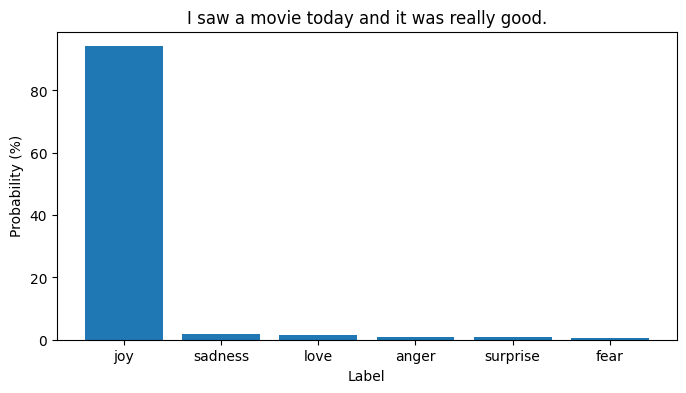

In [71]:
preds_df = pd.DataFrame(pred_model[0])

plt.figure(figsize=(8,4))
plt.bar(preds_df["label"], preds_df["score"] * 100, color="C0")
plt.ylabel("Probability (%)")
plt.xlabel("Label")
plt.title(custom_tweet)
plt.show()